# 🌟 COSMIC v0.0.1 - Compatibilidad Automática

**Este notebook ha sido actualizado para COSMIC v0.0.1**

## ✨ Mejoras Disponibles
- **Estructura modular**: `cosmic.core`, `cosmic.io`, `cosmic.preprocess`, `cosmic.analysis`
- **Imports modernos**: Específicos y organizados
- **API mejorada**: Mejor manejo de errores y configuración
- **Compatibilidad total**: El código existente sigue funcionando

## 🔄 Migración Opcional
Para usar las nuevas funcionalidades:
```python
# Nuevo (recomendado)
from cosmic.analysis.analyzer import ClusterAnalyzer
from cosmic.core.clustering import Clustering
from cosmic.io.loader import DataLoader

# Legacy (sigue funcionando)
from COSMIC import ClusterAnalyzer
from clustering import HDBSCANClustering
from data_loader import DataLoader
```

📚 **Documentación**: `/docs/reference/NOTEBOOK_MIGRATION_GUIDE.md`

In [4]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import arviz as az
import pymc as pm
from astropy.table import QTable

In [5]:
rng = np.random.default_rng(seed=42)
N = 256

sim_data = QTable()

# we generate the true distances from a Gaussian and convert to parallax values:
true_sc_dist = 500 * u.pc
true_sc_std = 8.7 * u.pc
true_sc_star_dist = (
    rng.normal(true_sc_dist.value, true_sc_std.value, size=N) * true_sc_dist.unit
)
sim_data["parallax"] = true_sc_star_dist.to(u.mas, u.parallax())

# heteroscedastic noise (i.e. each star has its own error bar):
sim_data["parallax_error"] = (10 ** rng.uniform(-2, -1.0, size=N)) * u.mas

# now we have to "observe" the true parallaxes with the generated uncertainties:
sim_data["parallax"] = (
    rng.normal(sim_data["parallax"].value, sim_data["parallax_error"].value)
    * sim_data["parallax"].unit
)

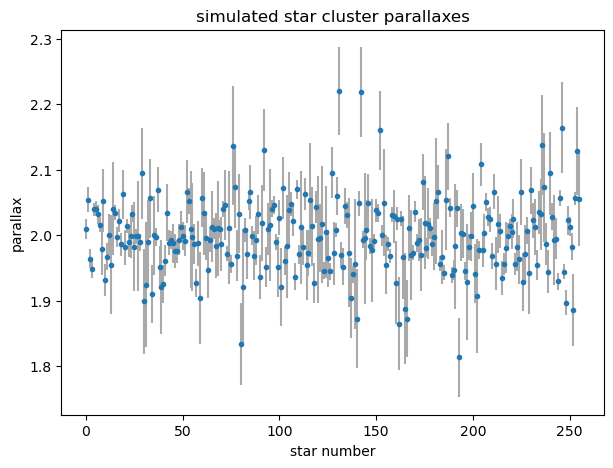

In [6]:
plt.figure(figsize=(7, 5))
plt.errorbar(
    np.arange(len(sim_data)),
    sim_data["parallax"].value,
    yerr=sim_data["parallax_error"].value,
    ls="none",
    marker="o",
    markersize=3,
    ecolor="#aaa",
)
plt.title("simulated star cluster parallaxes")
plt.xlabel("star number")
plt.ylabel("parallax");

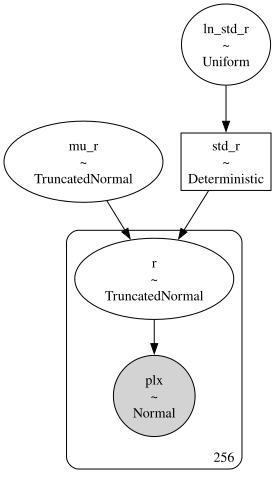

In [7]:
with pm.Model() as plx_model:
    # This is the (hyper)prior on the mean distance to the star cluster. Let's assume
    # that we have some prior knowledge about the distance to this cluster, and so we
    # set a broad normal distribution prior on its distance. However, we know that
    # distances can't be negative, so we use a truncated normal distribution (truncated
    # to values > 0) instead:
    mu_r = pm.TruncatedNormal("mu_r", mu=1.0, sigma=2.0, lower=0, upper=np.inf)

    # This is the (hyper)prior on ln(sigma), the log of the standard deviation of the
    # star cluster's distance (i.e. the physical size of the cluster along the line of
    # sight).
    ln_std_r = pm.Uniform("ln_std_r", -8, 0)

    # We will sample over ln(sigma), but we need the value of sigma (standard deviation)
    # to plug into the model we use for the cluster. We can transform the parameter to
    # a new un-logged value, but we need to tell pymc that this is not a new random
    # variable: the relationship between these parameters is a deterministic tranform
    std_r = pm.Deterministic("std_r", pm.math.exp(ln_std_r))

    # With parameters to represent the cluster mean distance and standard deviation,
    # we can now define the model for the distances to each star. Here we will again use
    # a truncated normal distribution (r>=0). Note that we specify the "shape" of this
    # parameter: This tells pymc to expect that we will have as many parameter values
    # as we have len(sim_data).
    # This line is equivalent to p(r | mu_r, sigma_r) in the math above
    r = pm.TruncatedNormal("r", mu_r, std_r, shape=len(sim_data), lower=0, upper=np.inf)

    # Finally, with the model-predicted individual stellar distances, we need to define
    # the relationship between our model and our data (i.e. the parallax measurements).
    # We assume that our parallax uncertainties are Gaussian, so we set up another
    # Normal distribution (not truncated) with an expression for the model predicted
    # parallaxes (1/r), and pass in the observed parallaxes with the "observed" keyword.
    # This line is equivalent to p(parallax | r) in the math above:
    pm.Normal(
        "plx",
        1 / r,
        observed=sim_data["parallax"].to_value(u.mas),
        sigma=sim_data["parallax_error"].to_value(u.mas),
    )

# Let's visualize the graphical model for this model and compare to the one above:
pm.model_to_graphviz(plx_model)

In [8]:
inv_var = 1 / sim_data["parallax_error"] ** 2
est_mean_plx = np.sum(sim_data["parallax"] * inv_var) / np.sum(inv_var)
est_mean_r = est_mean_plx.to_value(u.kpc, u.parallax())

In [9]:
with plx_model:
    samples = pm.sample(
        tune=2000,
        draws=1000,
        initvals={
            "mu_r": est_mean_r,
            "ln_std_r": -3.0,
            "r": np.full(len(sim_data), est_mean_r),
        },
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_r, ln_std_r, r]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 4 seconds.


In [10]:
# the "~r" below means "not r"
az.summary(samples, var_names=["~r"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_r,0.500,0.001,0.499,0.502,0.000,0.000,5437.0,2943.0,1.0
ln_std_r,-4.787,0.077,-4.922,-4.632,0.002,0.001,1560.0,1694.0,1.0
std_r,0.008,0.001,0.007,0.010,0.000,0.000,1560.0,1694.0,1.0


In [11]:
az.summary(samples, coords={"r_dim_0": np.arange(5)})

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_r,0.500,0.001,0.499,0.502,0.000,0.000,5437.0,2943.0,1.0
ln_std_r,-4.787,0.077,-4.922,-4.632,0.002,0.001,1560.0,1694.0,1.0
r[0],0.498,0.003,0.492,0.505,0.000,0.000,7153.0,2074.0,1.0
r[1],0.490,0.004,0.482,0.498,0.000,0.000,6033.0,2826.0,1.0
r[2],0.508,0.003,0.502,0.514,0.000,0.000,6836.0,2870.0,1.0
r[3],0.511,0.003,0.505,0.517,0.000,0.000,7280.0,2661.0,1.0
r[4],0.491,0.002,0.487,0.496,0.000,0.000,6468.0,2909.0,1.0
std_r,0.008,0.001,0.007,0.010,0.000,0.000,1560.0,1694.0,1.0


/Users/notluquis/miniconda3/lib/python3.11/site-packages/arviz/plots/pairplot.py:232: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  gridsize = int(dataset.dims["draw"] ** 0.35)


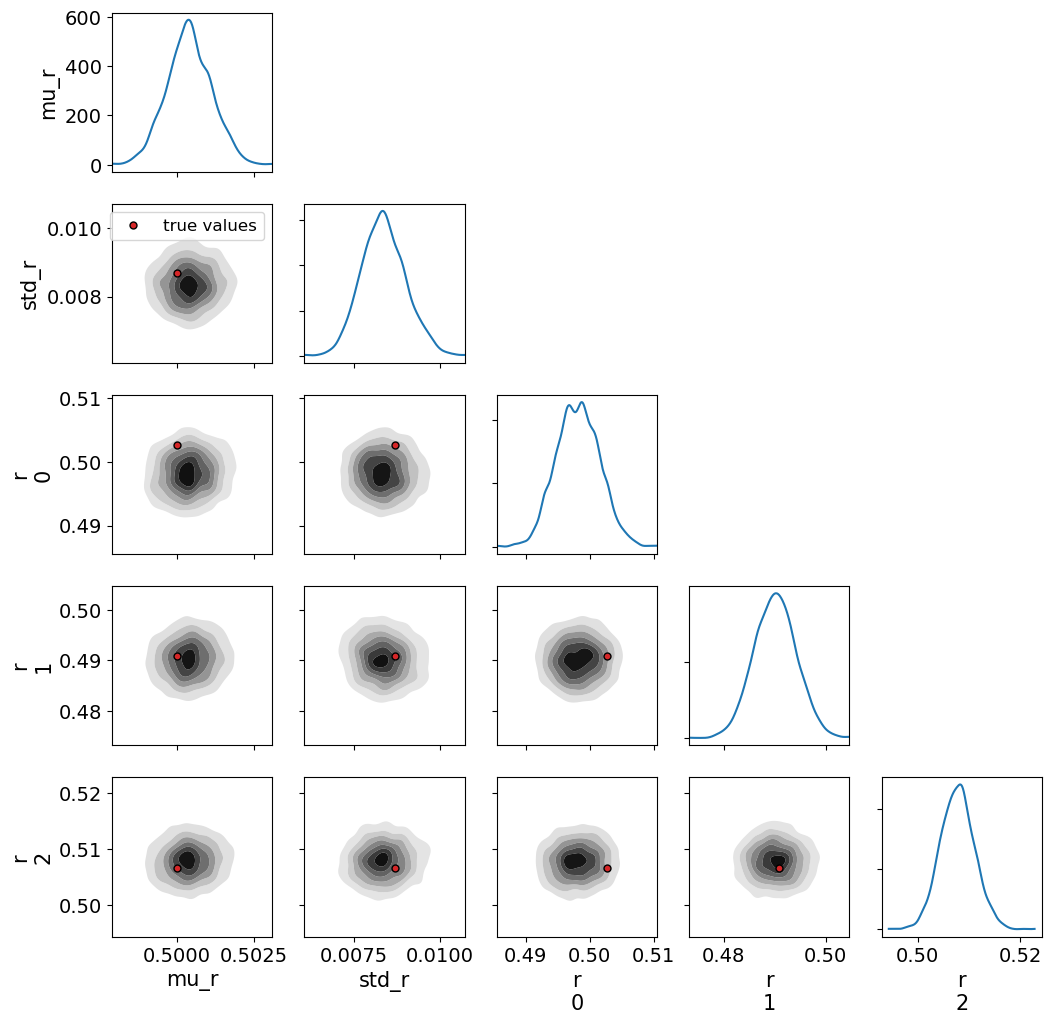

In [12]:
axes = az.plot_pair(
    samples,
    var_names=["mu_r", "std_r", "r"],
    marginals=True,
    kind="kde",
    kde_kwargs=dict(contourf_kwargs=dict(cmap="Greys"), contour_kwargs=dict(alpha=0.0)),
    figsize=(12, 12),
    reference_values={
        "mu_r": true_sc_dist.to_value(u.kpc),
        "std_r": true_sc_std.to_value(u.kpc),
        "r 0": true_sc_star_dist.to_value(u.kpc)[0],
        "r 1": true_sc_star_dist.to_value(u.kpc)[1],
        "r 2": true_sc_star_dist.to_value(u.kpc)[2],
    },
    reference_values_kwargs=dict(
        color="tab:red", markersize=5, label="true values", linestyle="none"
    ),
    coords={"r_dim_0": np.arange(3)},
)
axes[1, 0].legend(fontsize=12);

In [15]:
from scipy.stats import norm

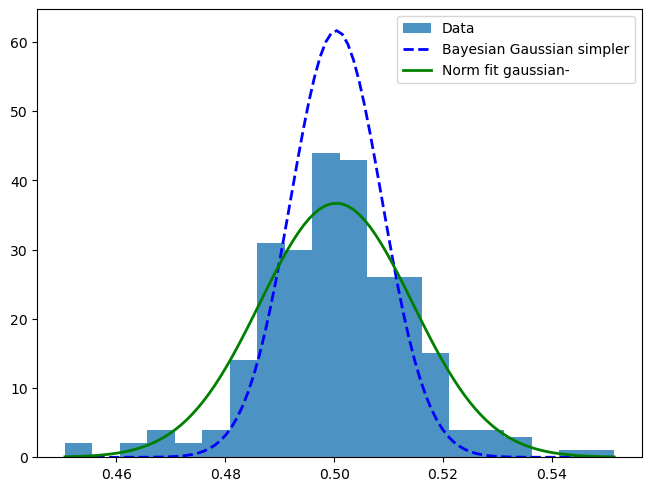

In [16]:
useful_data = sim_data

mu2 = samples.posterior['mu_r'].mean()
std2 = samples.posterior['std_r'].mean()

# Calculate the total number of observations
total_count = len(useful_data['parallax'])

# Histogram bin calculation for consistent scaling
counts, bin_edges = np.histogram(1/useful_data['parallax'], bins='auto')
bin_widths = np.diff(bin_edges)
average_bin_width = np.mean(bin_widths)

# Generate a finely spaced range of x-values for smoother curves
x_values = np.linspace(np.min(1/useful_data['parallax']), np.max(1/useful_data['parallax']), 100)

# Calculate the PDF of the Gaussian with predefined parameters
pdf_predefined2 = norm.pdf(x_values, mu2, std2) * total_count * average_bin_width

# Use norm.fit to estimate the parameters from the data
mu_fit, std_fit = norm.fit(1/useful_data['parallax'])
pdf_fit = norm.pdf(x_values, mu_fit, std_fit) * total_count * average_bin_width

# Plotting
fig, ax = plt.subplots(1, 1, layout='constrained')
# Histogram of the data
ax.hist(1/useful_data['parallax'], bins='auto', alpha=0.8, stacked=True, label='Data')
# Predefined Gaussian curve
#ax.plot(x_values, pdf_predefined, 'r.-', linewidth=2, label='Bayesian Gaussian')
ax.plot(x_values, pdf_predefined2, 'b--', linewidth=2, label='Bayesian Gaussian simpler')
# Fitted Gaussian curve
ax.plot(x_values, pdf_fit, 'g-', linewidth=2, label='Norm fit gaussian-')
ax.legend()
plt.show()
